# EC. Primer Parcial — Proyecto Práctico HPC

**Asignatura:** Cómputo de Alto Rendimiento

**Integrantes:**
1. Diego Cortes Zermeño (@DiegoZerm)
2. Cesar Ivan Ramirez Castañon (@tprogcesarramirez-dotcom)
3. Irving Nahir Ferrusca Jaimez (@irvingjaimez)

**Objetivo:** comparar la ejecución secuencial y paralela de un programa en Python que procesa una cantidad considerable de datos, midiendo el tiempo de ejecución, el *Speedup* y la eficiencia con 1, 2 y 4 workers.

## 1. Importación de Librerías y Módulos

Importamos las librerías necesarias para el procesamiento matemático, el paralelismo y la graficación de resultados.

In [1]:
import time
import math
import multiprocessing as mp
import numpy as np
import matplotlib.pyplot as plt

print("Librerías cargadas correctamente.")
print(f"Núcleos lógicos detectados en el sistema: {mp.cpu_count()}")

Librerías cargadas correctamente.
Núcleos lógicos detectados en el sistema: 8


## 2. Definición de Algoritmos (Secuencial y Paralelo)

Cada elemento $x$ del vector de datos se procesa con la función propuesta en la práctica:

$$f(x) = \sqrt{x} + x^2 + \sin(x) + \cos(x) + \log(x)$$

La función `process_chunk` recorre un bloque de datos y acumula $f(x)$ para cada elemento. Está definida en el módulo `hpc_utils.py` (y no dentro del notebook) para que los procesos del `Pool` puedan importarla también en Windows y macOS, donde `multiprocessing` crea los procesos con el método *spawn*.

La versión **secuencial** procesa todo el vector en un solo proceso y mide su tiempo con `time.perf_counter()`.

In [2]:
from hpc_utils import process_chunk


def generate_data(n_elements=25_000_000):
    """Genera un vector de datos continuos (1, 2, ..., n) para procesar."""
    return np.arange(1, n_elements + 1, dtype=np.float64)


def run_sequential(data):
    """Ejecuta el algoritmo en un solo proceso (secuencial)."""
    start = time.perf_counter()
    result = process_chunk(data)
    end = time.perf_counter()
    return end - start, result

### Paralelización con `multiprocessing.Pool`

Python tiene el *Global Interpreter Lock* (GIL), que impide que varios hilos ejecuten código Python al mismo tiempo. Por eso usamos **procesos** en lugar de hilos: cada proceso tiene su propio intérprete y puede usar un núcleo distinto del CPU.

La versión **paralela**:
1. Divide el vector en `num_workers` bloques del mismo tamaño con `np.array_split`.
2. Crea un `Pool` con `num_workers` procesos.
3. Cada proceso ejecuta `process_chunk` sobre su bloque (`pool.map`).
4. Suma los resultados parciales.

El tiempo medido incluye la creación de los procesos y el envío de los datos, que es el costo real (*overhead*) de paralelizar.

In [3]:
def run_parallel(data, num_workers):
    """Ejecuta el algoritmo dividiendo el vector entre múltiples workers (paralelo)."""
    chunks = np.array_split(data, num_workers)
    start = time.perf_counter()
    with mp.Pool(processes=num_workers) as pool:
        results = pool.map(process_chunk, chunks)
    end = time.perf_counter()
    return end - start, sum(results)

## 3. Experimentación y Benchmarking

En esta sección se ejecutan las pruebas de rendimiento midiendo el tiempo de ejecución de:
1. La versión **secuencial**.
2. La versión **paralela** con 1, 2 y 4 workers.

Cada configuración se evalúa **3 veces** para obtener los tiempos promedio, el **Speedup** ($S_p = T_1 / T_p$) y la **Eficiencia** ($E_p = S_p / p$).

In [4]:
DATA_SIZE = 25_000_000
WORKERS = [1, 2, 4]
REPETITIONS = 3

print(f"Generando vector de datos con {DATA_SIZE:,} elementos...")
dataset = generate_data(DATA_SIZE)

# Medición de la versión secuencial pura
print("\nEvaluando versión Secuencial:")
seq_times = []
for r in range(1, REPETITIONS + 1):
    t_seq, _ = run_sequential(dataset)
    seq_times.append(t_seq)
    print(f"  Prueba {r}: {t_seq:.4f} s")

# Medición paralela con Pool (1, 2 y 4 workers)
raw_results = {}
for w in WORKERS:
    print(f"\nEvaluando con Pool ({w} Worker/s):")
    times_w = []
    for r in range(1, REPETITIONS + 1):
        t_par, _ = run_parallel(dataset, num_workers=w)
        times_w.append(t_par)
        print(f"  Prueba {r}: {t_par:.4f} s")
    raw_results[w] = times_w

# Promedios y métricas HPC
t_seq_avg = np.mean(seq_times)
avg_times = [np.mean(raw_results[w]) for w in WORKERS]
T1 = avg_times[0]  # Tiempo base con Pool de 1 worker

speedups = [T1 / Tp for Tp in avg_times]
efficiencies = [Sp / p for Sp, p in zip(speedups, WORKERS)]

print(f"\nTiempo promedio secuencial puro: {t_seq_avg:.4f} s")

Generando vector de datos con 25,000,000 elementos...

Evaluando versión Secuencial:
  Prueba 1: 18.7543 s
  Prueba 2: 18.8584 s
  Prueba 3: 17.9187 s

Evaluando con Pool (1 Worker/s):
  Prueba 1: 19.8191 s
  Prueba 2: 19.3829 s
  Prueba 3: 19.8956 s

Evaluando con Pool (2 Worker/s):
  Prueba 1: 11.1428 s
  Prueba 2: 12.7501 s
  Prueba 3: 13.3965 s

Evaluando con Pool (4 Worker/s):
  Prueba 1: 8.3382 s
  Prueba 2: 8.4765 s
  Prueba 3: 8.0853 s

Tiempo promedio secuencial puro: 18.5105 s


## 4. Tabla Resumen de Métricas HPC

Resumen de los tiempos promedio de ejecución, Speedup y Eficiencia calculados a partir de los datos experimentales.

In [5]:
print("=" * 65)
print(f"{'Configuración':<18}{'Tiempo Prom (s)':<18}{'Speedup (Sp)':<15}{'Eficiencia (Ep)':<14}")
print("=" * 65)
print(f"{'Secuencial':<18}{t_seq_avg:<18.4f}{'-':<15}{'-':<14}")
for w, t, s, e in zip(WORKERS, avg_times, speedups, efficiencies):
    label = f"{w} Worker(s)"
    print(f"{label:<18}{t:<18.4f}{s:<15.4f}{e*100:<13.2f}%")
print("=" * 65)

Configuración     Tiempo Prom (s)   Speedup (Sp)   Eficiencia (Ep)
Secuencial        18.5105           -              -             
1 Worker(s)       19.6992           1.0000         100.00       %
2 Worker(s)       12.4298           1.5848         79.24        %
4 Worker(s)       8.3000            2.3734         59.34        %


## 5. Visualización de Rendimiento

Generación automatizada de las gráficas de evaluación del sistema:
1. **Workers vs. Tiempo de Ejecución**
2. **Workers vs. Speedup** (medido vs. ideal)
3. **Workers vs. Eficiencia (%)**

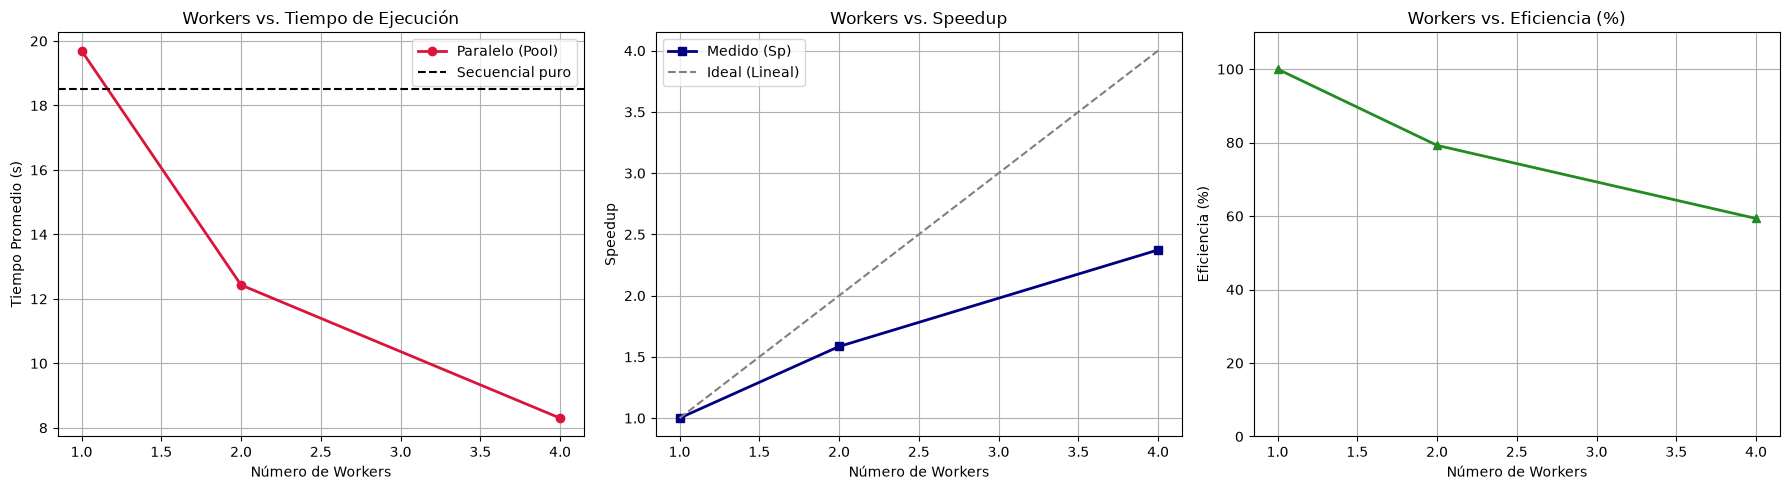

Gráfica guardada exitosamente como 'hpc_performance_results.png'.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Workers vs Tiempo
axes[0].plot(WORKERS, avg_times, marker='o', color='crimson', linewidth=2, label='Paralelo (Pool)')
axes[0].axhline(y=t_seq_avg, color='black', linestyle='--', label='Secuencial puro')
axes[0].set_title('Workers vs. Tiempo de Ejecución')
axes[0].set_xlabel('Número de Workers')
axes[0].set_ylabel('Tiempo Promedio (s)')
axes[0].legend()
axes[0].grid(True)

# 2. Workers vs Speedup
axes[1].plot(WORKERS, speedups, marker='s', color='navy', linewidth=2, label='Medido (Sp)')
axes[1].plot(WORKERS, WORKERS, '--', color='gray', label='Ideal (Lineal)')
axes[1].set_title('Workers vs. Speedup')
axes[1].set_xlabel('Número de Workers')
axes[1].set_ylabel('Speedup')
axes[1].legend()
axes[1].grid(True)

# 3. Workers vs Eficiencia
axes[2].plot(WORKERS, [e * 100 for e in efficiencies], marker='^', color='forestgreen', linewidth=2)
axes[2].set_title('Workers vs. Eficiencia (%)')
axes[2].set_xlabel('Número de Workers')
axes[2].set_ylabel('Eficiencia (%)')
axes[2].set_ylim(0, 110)
axes[2].grid(True)

plt.tight_layout()
plt.savefig('hpc_performance_results.png', dpi=300)
plt.show()
print("Gráfica guardada exitosamente como 'hpc_performance_results.png'.")